In [35]:
# This code loads a particular model from the saved models.
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from torch.linalg import eigvalsh
import pandas as pd
import copy
import matplotlib.pyplot as plt



num_iter = 10000

torch.backends.cudnn.enabled = False
dtype = torch.float64
torch.set_default_dtype(dtype)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device: ", device)

# Parameters

Nc = 3
g5_sq = (12*np.pi**2)/Nc

omega_a1 = torch.tensor([1.23, 1.655], device=device)  # in GeV
omega_a2 = torch.tensor([1.3182, 1.706], device=device)  # in GeV
omega_rho = torch.tensor([0.77526, 1.465, 1.72], device=device)
omega_f0 = torch.tensor([0.475, 0.99, torch.nan, 1.522, 1.733, 1.982], device=device)  # in GeV
omega_pi = torch.tensor([0.134, 1.3, 1.8], device=device)  # in GeV

z_max = 15.0
h = 0.15
z_ini = h

def V_k_fn(v_z, k1, k2):
    return (k2)*v_z**3 + k1*v_z**2

fpi_sq = (92.4e-3)**2  # in GeV^2
mpi_sq = (139.57e-3)**2  # in GeV^2

zeta = np.sqrt(Nc)/(2*np.pi)

def Sigma_fn(theta, scale=1):
    return 0.01 + (0.03 - 0.01)*torch.sigmoid(theta*scale)

def ab_fn(theta, L):
    Sigma = Sigma_fn(theta)
    m_q = fpi_sq*mpi_sq/(2*Sigma)
    alpha = zeta*m_q*L
    beta = (Sigma/zeta)*(L**3)

    return alpha, beta

# DEFINE A(z) THE NEURAL NETWORK
n_neurons = [50, 50, 50, 50]

class A_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [-1, 1]
        #z = 2.0 * (z) / (z_max) - 1.0

        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()


# DEFINE v(z)THE NEURAL NETWORK
#n_neurons = [20, 20, 20, 20] # number of neurons in each hidden layer

class v_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()
    
def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        #torch.nn.init.xavier_normal_(m.weight)

def v_z_fn(z, model_v, theta, L):
    alpha, beta = ab_fn(theta, L)
    return (alpha*z + beta*z**3 + model_v(z)*z**4)/(1+z**3)

def A_z_fn(z, model_A):
    return -torch.log(z) + z*model_A(z)*0.1

def B2_dash_z_fn(exp_2A_z, v_z, dv_dz, d2v_dz2, k1, k2):
    return (d2v_dz2 - exp_2A_z*(-3*v_z - V_k_fn(v_z, k1, k2)))/dv_dz


def V_mesons(model_A, model_v,  k1, k2, theta, L, z=None):
    if z is None:
        z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]
    
    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2,  k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    d2B2_dz2 = autograd.grad(dB2_dz, z, torch.ones_like(dB2_dz), create_graph=True)[0]
    d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

    V_rho = 0.25*dB1_dz**2 - 0.5*d2B1_dz2
    V_a1 = V_rho + g5_sq*exp_2A*v_z**2
    V_a2 = 0.25*dB2_dz**2 - 0.5*d2B2_dz2
    V_f0 = V_a2 + exp_2A*(-3 - (2*k1*v_z + 3*(k2)*v_z**2)) 

    return V_rho, V_a1, V_a2, V_f0

def eigenvalues_square_fn(model_A, model_v,  k1, k2, theta, L, no_eigenvalues = (2, 2, 2, 2)):
    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L)
    diag_elem_rho = 2 + V_rho*h**2
    diag_elem_a1 = 2 + V_a1*h**2
    diag_elem_a2 = 2 + V_a2*h**2
    diag_elem_f0 = 2 + V_f0*h**2

    off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

    mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a1 = (torch.diag(diag_elem_a1) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a2 = (torch.diag(diag_elem_a2) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_f0 = (torch.diag(diag_elem_f0) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2

    eigenvalues_rho = eigvalsh(mat_rho)[:no_eigenvalues[0]]/(L**2)
    eigenvalues_a1 = eigvalsh(mat_a1)[:no_eigenvalues[1]]/(L**2)
    eigenvalues_a2 = eigvalsh(mat_a2)[:no_eigenvalues[2]]/(L**2)
    eigenvalues_f0 = eigvalsh(mat_f0)[:no_eigenvalues[3]]/(L**2)

    return eigenvalues_rho, eigenvalues_a1, eigenvalues_a2, eigenvalues_f0

################################################################################################################################
################################################ Loss Functions ################################################################
################################################################################################################################

# Mass loss
def mass_loss_fn(model_A, model_v,  k1, k2, theta, L, train_data=(omega_rho, omega_a1, omega_a2, omega_f0)):
    omega_rho, omega_a1, omega_a2, omega_f0 = train_data

    mbyL_rho, mbyL_a1, mbyL_a2, mbyL_f0 = eigenvalues_square_fn(model_A, model_v, k1, k2, theta, L, (len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0)))
    
    # remove None values from omega_f0, omega_rho, omega_a1, omega_a2 and corresponding mbyL_f0, mbyL_rho, mbyL_a1, mbyL_a2 values
    mask_f0 = ~torch.isnan(omega_f0)
    mask_rho = ~torch.isnan(omega_rho)
    mask_a1 = ~torch.isnan(omega_a1)
    mask_a2 = ~torch.isnan(omega_a2)


    omega_f0 = omega_f0[mask_f0]
    omega_rho = omega_rho[mask_rho]
    omega_a1 = omega_a1[mask_a1]
    omega_a2 = omega_a2[mask_a2]

    mbyL_f0 = mbyL_f0[mask_f0]
    mbyL_rho = mbyL_rho[mask_rho]
    mbyL_a1 = mbyL_a1[mask_a1]
    mbyL_a2 = mbyL_a2[mask_a2]

    rho_mass_loss = torch.abs(mbyL_rho - omega_rho**2)/omega_rho**2
    a1_mass_loss = torch.abs(mbyL_a1 - omega_a1**2)/omega_a1**2
    a2_mass_loss = torch.abs(mbyL_a2 - omega_a2**2)/omega_a2**2
    f0_mass_loss = torch.abs(mbyL_f0 - omega_f0**2)/omega_f0**2

    f0_mass_loss[0] *= 0.1 # give less weight to the lightest f0 meson since its nature is not well established

    sum_loss = (rho_mass_loss.sum() + a1_mass_loss.sum() + a2_mass_loss.sum() + f0_mass_loss.sum()).detach()

    rho_scaling = rho_mass_loss.detach()/sum_loss
    a1_scaling = a1_mass_loss.detach()/sum_loss
    a2_scaling = a2_mass_loss.detach()/sum_loss
    f0_scaling = f0_mass_loss.detach()/sum_loss

    rho_mass_loss = (rho_mass_loss * rho_scaling).mean()
    a1_mass_loss = (a1_mass_loss * a1_scaling).mean()
    a2_mass_loss = (a2_mass_loss * a2_scaling).mean()
    f0_mass_loss = (f0_mass_loss * f0_scaling).mean()

    return rho_mass_loss, a1_mass_loss, a2_mass_loss, f0_mass_loss

def pos_v_dash_loss_fn(model_v, theta, L):
    z = torch.rand(100, device=device, requires_grad=True)*z_max
    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    return nn.ReLU()(-dv_dz).sum()

def A_z_IR_loss_fn(model_A):
    z = torch.tensor([z_max], device=device, requires_grad=True)
    A_z = A_z_fn(z, model_A)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    return nn.ReLU()(A_z + torch.log(z)-1.5).sum() + nn.ReLU()(dA_dz).sum()

def pot_dash_IR_loss_fn(model_A, model_v, k1, k2, theta, L): # potential should be increasing at IR
    #z = torch.linspace(z_max*(0.8), z_max, 10, device=device, requires_grad=True)
    z = torch.rand(1, device=device, requires_grad=True)*(z_max*0.2) + z_max*0.8

    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v, k1, k2, theta, L, z)
    V_dash_rho = autograd.grad(V_rho, z, torch.ones_like(V_rho), create_graph=True)[0]
    V_dash_a2 = autograd.grad(V_a2, z, torch.ones_like(V_a2), create_graph=True)[0]
    return nn.ReLU()(-V_dash_rho).sum() + nn.ReLU()(-V_dash_a2).sum()



Using device:  cpu


In [36]:
folder_name = 'saved/7/'

params = {}

with open(folder_name + 'params.txt', 'r') as f:
    for line in f:
        if ':' in line:
            key, value = line.split(':', 1)
            params[key.strip()] = value.strip()

for key, value in params.items():
    print(f"{key}: {value}")

min_loss: 0.004938008980505407
k1: -5.239963228105245
k2: 10.751180636525508
theta: 3.3267964377270856
L: 1.0000002422634098


In [37]:
model_A = A_LinearNN().to(device)
model_v = v_LinearNN().to(device)

model_A.load_state_dict(torch.load(folder_name + 'model_A.pth', map_location=device))
model_v.load_state_dict(torch.load(folder_name + 'model_v.pth', map_location=device))

k1 = float(params['k1'])
k2 = float(params['k2'])
theta = torch.tensor(float(params['theta']))
L = float(params['L'])

/tmp/ipykernel_1577240/1428350227.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_A.load_state_dict(torch.load(folder_name + 'model_A.pth', map_location=device))
/

# $f_\pi$ Calculation

In [39]:
dz = 0.01
z = torch.arange(dz, z_max, dz, device=device, requires_grad=True)

A_z = A_z_fn(z, model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]

v_z = v_z_fn(z, model_v, theta, L)
dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2,  k1, k2)
dB1_dz = dB2_dz + 2*dA_dz

d2B2_dz2 = autograd.grad(dB2_dz, z, torch.ones_like(dB2_dz), create_graph=True)[0]
d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

dphi_dz = dB2_dz + 3*dA_dz

# convert all to numpy arrays
z = z.detach().cpu().numpy()
A_z = A_z.detach().cpu().numpy()
exp_2A = exp_2A.detach().cpu().numpy()
dA_dz = dA_dz.detach().cpu().numpy()
d2A_dz2 = d2A_dz2.detach().cpu().numpy()
v_z = v_z.detach().cpu().numpy()
dv_dz = dv_dz.detach().cpu().numpy()
d2v_dz2 = d2v_dz2.detach().cpu().numpy()
dB2_dz = dB2_dz.detach().cpu().numpy()
dB1_dz = dB1_dz.detach().cpu().numpy()
d2B2_dz2 = d2B2_dz2.detach().cpu().numpy()
d2B1_dz2 = d2B1_dz2.detach().cpu().numpy()
dphi_dz = dphi_dz.detach().cpu().numpy()

#solve for phi(z) by integrating dphi/dz
phi_z = np.zeros_like(dphi_dz)
phi_z[0] = 0.0 + dphi_dz[0]*dz
for j in range(1, len(z)):
    phi_z[j] = phi_z[j-1] + dphi_dz[j]*dz

B1_z = phi_z - A_z

# create interpolating functions for all the above arrays
from scipy.interpolate import interp1d

dB1_dz_interp = interp1d(z, dB1_dz, kind='cubic', fill_value='extrapolate')
v_z_interp = interp1d(z, v_z, kind='cubic', fill_value='extrapolate')
A_z_interp = interp1d(z, A_z, kind='cubic', fill_value='extrapolate')
phi_z_interp = interp1d(z, phi_z, kind='cubic', fill_value='extrapolate')
B1_z_interp = interp1d(z, B1_z, kind='cubic', fill_value='extrapolate')


In [40]:
from scipy.integrate import solve_bvp

# de for a_0(0, z)
def de_a0(z, a):
    a0, da0_dz = a
    d2a0_dz2 = dB1_dz_interp(z)*da0_dz + g5_sq*v_z_interp(z)**2 * np.exp(2*A_z_interp(z))*a0
    return np.vstack((da0_dz, d2a0_dz2))

# boundary conditions for a_0(0, z) is a_0(0) = 1, da_0/dz(z_max) = 0
def bc_a0(ya, yb):
    return np.array([ya[0] - 1, yb[1]])

z_bvp = np.linspace(dz, z_max, 1000)
a0_init = np.zeros((2, z_bvp.size))
a0_init[0] = 1.0  # initial guess for a_0

result_a0 = solve_bvp(de_a0, bc_a0, z_bvp, a0_init)
f_pi = np.sqrt(-result_a0.y[1][0]*np.exp(-B1_z_interp(result_a0.x[0]))/g5_sq)
print("Predicted f_pi =", 1000*f_pi, "MeV")
print("Experimental f_pi =", 92.4, "+-", 0.35, "MeV")


Predicted f_pi = 90.82218504197152 MeV
Experimental f_pi = 92.4 +- 0.35 MeV


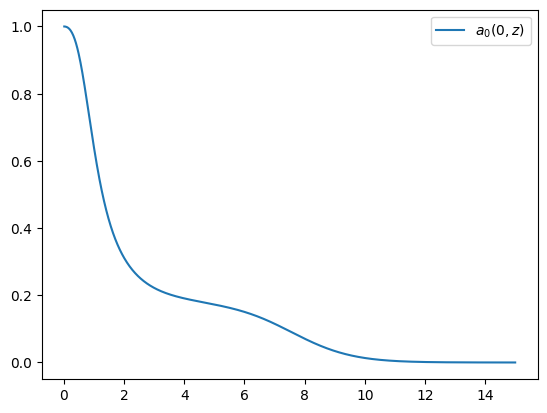

In [41]:
plt.plot(result_a0.x, result_a0.y[0], label='$a_0(0, z)$')
plt.legend()
plt.show()

# $g_{\rho\pi\pi}$ Calculation

In [42]:
# rho meson wavefunction
from torch.linalg import eigh
from scipy.integrate import simpson

dz = 0.01
z = torch.arange(dz, z_max, dz, requires_grad=True)

V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L, z=z)

diag_elem_rho = 2 + V_rho*dz**2

off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/dz**2

eigvals_rho, eigvecs_rho = eigh(mat_rho.cpu())

eigvecs_rho = eigvecs_rho.cpu().detach().numpy()

psi_0_rho = eigvecs_rho[:, 0]
psi_0_rho = psi_0_rho/np.sqrt(simpson(psi_0_rho**2, z.cpu().detach().numpy(), axis=0))

V_0_z = -psi_0_rho*np.exp(B1_z_interp(z.cpu().detach().numpy())/2)



In [43]:
# approximate method (without solving for pi and xi)

a0_z, da0_dz = result_a0.sol(z.cpu().detach().numpy())

integrand = V_0_z*np.exp(-B1_z_interp(z.cpu().detach().numpy()))*(da0_dz**2/g5_sq + np.exp(2*A_z_interp(z.cpu().detach().numpy()))*v_z_interp(z.cpu().detach().numpy())**2*a0_z**2)

g_rho0_pi_pi = np.sqrt(g5_sq)*simpson(integrand, z.cpu().detach().numpy())/f_pi**2
print("Predicted g_rho0_pi_pi =", g_rho0_pi_pi)

Predicted g_rho0_pi_pi = 3.7924320281390473


In [9]:
from scipy.linalg import eig

v_z = v_z_fn(z, model_v, theta, L)
dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

A_z = A_z_fn(z, model_A)
exp_2A = torch.exp(2*A_z)
dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, k1, k2)
dB1_dz = dB2_dz + 2*dA_dz

omega_z = 2*dv_dz/v_z - dB2_dz
C_z = g5_sq*exp_2A*v_z**2

# making M1 matrix
diag_elem_M1 = -2/dz**2 * torch.ones_like(z)
off_diag_elem_M1_plus = 1/dz**2 + omega_z[:-1]/(2*dz)
off_diag_elem_M1_minus = 1/dz**2 - omega_z[1:]/(2*dz)
M1 = torch.diag(diag_elem_M1) + torch.diag(off_diag_elem_M1_plus, diagonal=1) + torch.diag(off_diag_elem_M1_minus, diagonal=-1)

M1[-1, -1] += 1/dz**2 + omega_z[-1]/(2*dz) # Neumann BC at IR

# making M2 matrix
M2 = torch.diag(C_z)

# making M3 matrix
diag_elem_M3 = -2/dz**2 - C_z
off_diag_elem_M3_plus = 1/dz**2 - dB1_dz[:-1]/(2*dz)
off_diag_elem_M3_minus = 1/dz**2 + dB1_dz[1:]/(2*dz)
M3 = torch.diag(diag_elem_M3) + torch.diag(off_diag_elem_M3_plus, diagonal=1) + torch.diag(off_diag_elem_M3_minus, diagonal=-1)

M3[-1, -1] += 1/dz**2 - dB1_dz[-1]/(2*dz) # Neumann BC IR

M = torch.zeros((2*len(z), 2*len(z)), device=device)
M[:len(z), :len(z)] = M1
M[len(z):, :len(z)] = M2
M[len(z):, len(z):] = M3

# make T = [[-1, 1], [0, 0]]
T = torch.zeros((2*len(z), 2*len(z)), device=device)
T[:len(z), :len(z)] = -1*torch.eye(len(z))
T[:len(z), len(z):] = torch.eye(len(z))

M = M.cpu().detach().numpy()
T = T.cpu().detach().numpy()
z = z.cpu().detach().numpy()

# solve generalized eigenvalue problem using scipy
eigvals, eigvecs = eig(M, T)

# sort eigenvalues and eigenvectors and take upto the length of omega_pi
idx = eigvals.real.argsort()
eigvals = eigvals.real[idx]#[:len(omega_pi)]
eigvecs = eigvecs[:, idx]#[:, :len(omega_pi)]

pi_0_z = eigvecs[:len(eigvecs)//2, 0].real
xi_0_z = eigvecs[len(eigvecs)//2:, 0].real

# calculate derivative of xi_0_z with respect to z. xi has boundary condition xi(0) = 0 and dxi/dz(z_max) = 0
d_xi_0_dz = np.zeros_like(xi_0_z)
d_xi_0_dz[0] = (xi_0_z[0] - 0)/dz
d_xi_0_dz[1:] = (xi_0_z[1:] - xi_0_z[:-1])/dz

In [10]:
integrand = V_0_z*np.exp(-B1_z_interp(z))*(d_xi_0_dz**2/g5_sq + v_z_interp(z)**2*np.exp(2*A_z_interp(z))*(pi_0_z - xi_0_z)**2)
integrand_norm = np.exp(-B1_z_interp(z))*(d_xi_0_dz**2/g5_sq + v_z_interp(z)**2*np.exp(2*A_z_interp(z))*(pi_0_z - xi_0_z)**2)

# integrate

integral = simpson(integrand, z)
integral_norm = simpson(integrand_norm, z)

g_rho0_pi_pi = np.sqrt(g5_sq)*integral/integral_norm

print("Predicted g_rho0_pi_pi =", g_rho0_pi_pi)

Predicted g_rho0_pi_pi = 3.7629798383090445


In [11]:
q_sq_arr = np.linspace(0, 6, 100)
F_pi_q_sq_arr = []

for q_sq in q_sq_arr:

    # de for V(q, z)
    def de_V_q_z(z, V):
        V_q_z, dV_q_dz = V
        d2V_q_dz2 = dB1_dz_interp(z)*dV_q_dz + q_sq*V_q_z
        return np.vstack((dV_q_dz, d2V_q_dz2))

    def bc_V_q_z(ya, yb):
        return np.array([ya[0] - 1, yb[1]])
    dz = 0.01
    z_bvp = np.linspace(dz, z_max, 1000)
    V_q_z_init = np.zeros((2, z_bvp.size))
    V_q_z_init[0] = 1.0  # initial guess for V(q, z)

    result_V_q_z = solve_bvp(de_V_q_z, bc_V_q_z, z_bvp, V_q_z_init)

    V_q_z = result_V_q_z.sol(z)[0]

    integrand = V_q_z*np.exp(-B1_z_interp(z))*(d_xi_0_dz**2/g5_sq + v_z_interp(z)**2*np.exp(2*A_z_interp(z))*(pi_0_z - xi_0_z)**2)
    integral = simpson(integrand, z)

    F_pi_q_sq = integral/integral_norm

    F_pi_q_sq_arr.append(F_pi_q_sq)




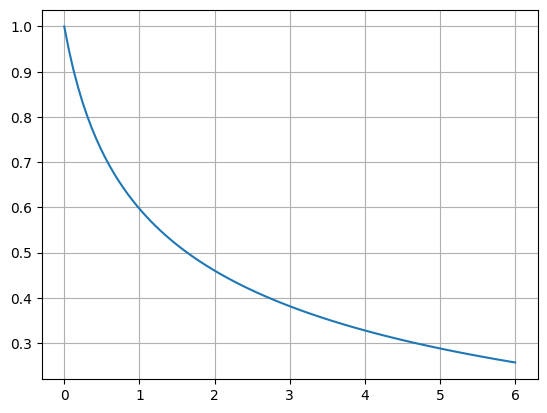

In [12]:
plt.plot(q_sq_arr, F_pi_q_sq_arr)
""" plt.ylim(0, 1)
plt.xlim(0, 6) """
plt.grid()